# Spatial Diagnostics: Moran's I across Distance Bands

This notebook tests for spatial autocorrelation (Moran's I) in the main outcome and explanatory variables across various distance bands (20km to 200km). The goal is to identify the range of spatial dependence to inform the selection of the Conley standard error distance cutoff.

In [1]:
pacman::p_load(sf, spdep, tidyverse, ggplot2, jsonlite)

PROJECT_ROOT <- ".."
setwd(PROJECT_ROOT)

pdf <- read_sf("Data/Processed/northParishFlows.shp")
coords <- st_coordinates(st_centroid(st_geometry(pdf)))

# Outcomes
outcomes <- c("muster", "primary", "seats")

# Explanatory (logged versions)
explanatory <- c("llandOwned", "lbigLand", "lotherLand")

# Distance bands in km
bands_km <- c(20, 50, 100, 150, 200)

# Function to compute Moran's I for a variable and distance band
get_moran <- function(var_name, d_max_km) {
  # d_max is in meters if BNG, so multiply by 1000
  nb <- dnearneigh(coords, 0, d_max_km * 1000)
  
  # Check for empty neighbors
  if (any(card(nb) == 0)) {
     # Some parishes might have no neighbors at small distances
     lw <- nb2listw(nb, style = "W", zero.policy = TRUE)
  } else {
     lw <- nb2listw(nb, style = "W")
  }
  
  res <- moran.test(pdf[[var_name]], lw, zero.policy = TRUE, na.action = na.omit)
  
  data.frame(
    variable = var_name,
    distance_km = d_max_km,
    moran_i = res$estimate[1],
    p_value = res$p.value
  )
}

results <- list()
for (v in c(outcomes, explanatory)) {
  for (d in bands_km) {
    results[[length(results) + 1]] <- get_moran(v, d)
  }
}

moran_df <- do.call(rbind, results)
row.names(moran_df) <- NULL
print(moran_df)


     variable distance_km      moran_i       p_value
1      muster          20 0.0457305934  1.180845e-21
2      muster          50 0.0283649410  1.363871e-46
3      muster         100 0.0111568935  1.696150e-33
4      muster         150 0.0042110787  2.466189e-18
5      muster         200 0.0021784365  2.713673e-17
6     primary          20 0.0386440871  2.512944e-16
7     primary          50 0.0210364129  2.478967e-27
8     primary         100 0.0067009286  2.920535e-14
9     primary         150 0.0023981509  2.956348e-08
10    primary         200 0.0003407621  2.554842e-03
11      seats          20 0.0892491023  1.268453e-76
12      seats          50 0.0401161050  7.796310e-91
13      seats         100 0.0239468626 1.622338e-140
14      seats         150 0.0090885677  2.481449e-69
15      seats         200 0.0007120574  4.352665e-05
16 llandOwned          20 0.1152176165 7.980860e-123
17 llandOwned          50 0.0772679468 2.458179e-318
18 llandOwned         100 0.0317128495 4.39344

## Visualizing Spatial Decay

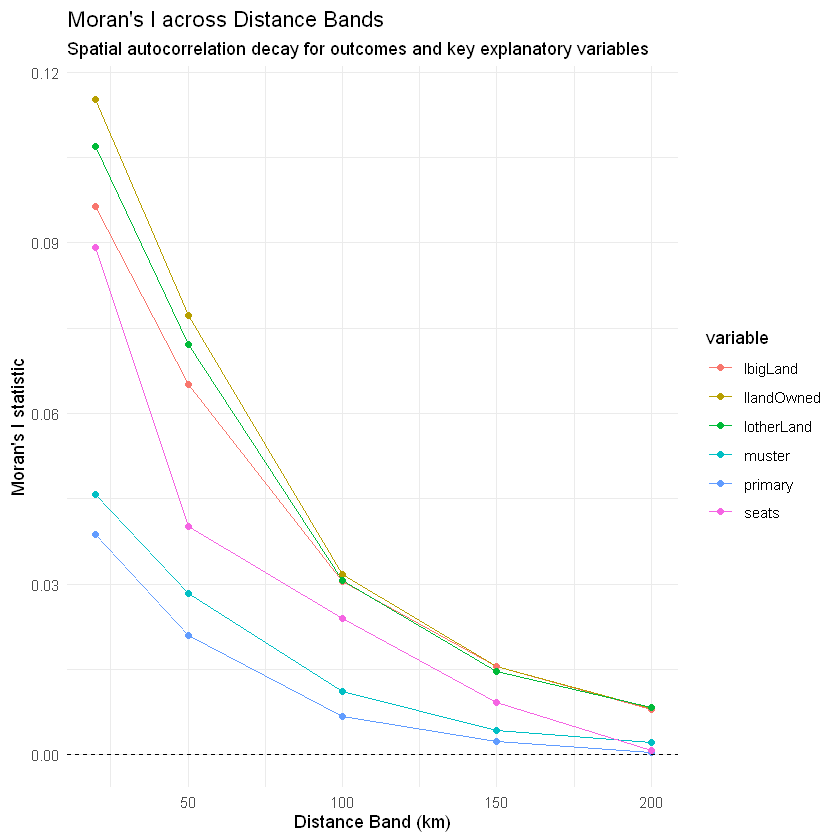

In [2]:
ggplot(moran_df, aes(x = distance_km, y = moran_i, color = variable, group = variable)) +
  geom_line() +
  geom_point() +
  geom_hline(yintercept = 0, linetype = "dashed") +
  theme_minimal() +
  labs(title = "Moran's I across Distance Bands",
       subtitle = "Spatial autocorrelation decay for outcomes and key explanatory variables",
       x = "Distance Band (km)",
       y = "Moran's I statistic")
